In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [117]:
# Data Preprocessing

def preprocess_data(data= pd.DataFrame()):
    df= data.copy()

    df['armour_jedai']= df['armour_jedai'].apply(lambda x: float(x[:-1]))
    df['armour_calmtrooper']= df['armour_calmtrooper'].apply(lambda x: float(x[:-1]))
    df['surprise_attack']= df['surprise_attack'].apply(lambda x: int(x))

    return df


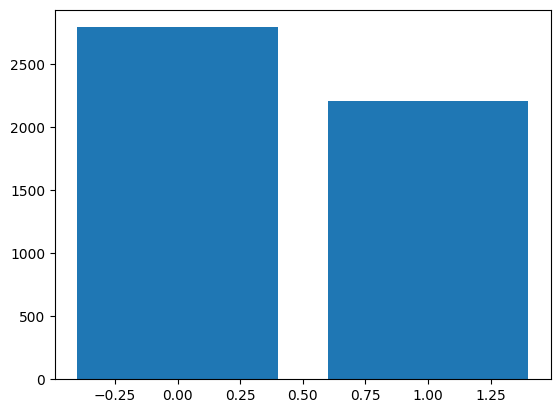

In [118]:
from sklearn.model_selection import train_test_split

train_df= pd.read_csv("train_galactic_wars.csv")
test_df= pd.read_csv("test_galactic_wars.csv")

X= preprocess_data(train_df.drop(columns=['FightID', 'winner']))
y= train_df['winner']

cat_cols= X.select_dtypes(include=['object', 'string']).columns.to_list()

X_train, X_eval, y_train, y_eval= train_test_split(X, y, train_size=0.8, stratify=y, random_state= seed)

X_test= preprocess_data(test_df.drop(columns=['FightID']))

plt.bar(train_df['winner'].value_counts().index, train_df['winner'].value_counts().values)
plt.show()

In [119]:
# Subtask 1

answer1= []

answer1.append({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': len(test_df[
        (test_df['fight_planet'] == 'Nabira') &
        (test_df['weather_conditions'] == 'Snow')
    ])
})

answer1= pd.DataFrame(answer1)
answer1.head()

,subtaskID,datapointID,answer
0,1,1,143


In [120]:
# Subtask 2

answer2= []

answer2.append({
    'subtaskID': 2,
    'datapointID': 2,
    'answer': len(train_df[train_df['weapon_calmtrooper'] == 'Experimental Weapon'])
})

train_df['weapon_calmtrooper'].apply(lambda x: 'Double Blaster' if x== 'Experimental Weapon' else x)

answer2= pd.DataFrame(answer2)
answer2.head()

,subtaskID,datapointID,answer
0,2,2,1646


In [121]:
# Subtask 3

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_subtask3= X_test.drop(columns=cat_cols)

scaler= StandardScaler()

X_subtask3= scaler.fit_transform(X_subtask3)

model = KMeans(
    n_clusters=3,
    max_iter=1000,
    n_init=50,
    verbose=False,
    random_state= seed,
)

predictions= model.fit_predict(X_subtask3)

answer3= []

for id_, pred in zip(test_df['FightID'], predictions):
    answer3.append({
        'subtaskID': 3,
        'datapointID': id_,
        'answer': pred
    })

answer3= pd.DataFrame(answer3)
answer3.head(5)

,subtaskID,datapointID,answer
0,3,1596,2
1,3,4432,1
2,3,486,2
3,3,6503,0
4,3,4650,1


In [122]:
# Subtask 4

from catboost import CatBoostClassifier

model= CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    cat_features= cat_cols,
    auto_class_weights='Balanced',
    eval_metric= 'TotalF1',
    early_stopping_rounds=200,
    random_state= seed
)

model.fit(
    X_train, y_train,
    eval_set=[(X_eval, y_eval)],
    verbose= False
)

predictions= model.predict(X_test)

answer4= []

for id_, pred in zip(test_df['FightID'], predictions):
    answer4.append({
        'subtaskID': 4,
        'datapointID': id_,
        'answer': pred
    })

answer4= pd.DataFrame(answer4)
answer4.head(5)

,subtaskID,datapointID,answer
0,4,1596,0
1,4,4432,1
2,4,486,0
3,4,6503,0
4,4,4650,1


In [123]:
answer= pd.concat([answer1, answer2, answer3, answer4])
answer.to_csv("submission.csv", index= False)